In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\LENOVO\Desktop\fraud-detection-risk-scoring\data\raw\creditcard.csv")

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.shape

(284807, 31)

In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [10]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1081)

In [12]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [14]:
duplicates = df[df.duplicated(keep=False)]
duplicates.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


In [15]:
duplicates["Class"].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [16]:
duplicates.groupby(list(df.columns)).size().value_counts().head()

2    611
4     81
3     66
5     10
9      2
Name: count, dtype: int64

In [17]:
df = df.drop_duplicates()

In [18]:
df.shape

(283726, 31)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [21]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [22]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [23]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [24]:
df.groupby("Class")["Amount"].mean()

Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64

In [25]:
df.groupby("Class")["Amount"].median()

Class
0    22.00
1     9.82
Name: Amount, dtype: float64

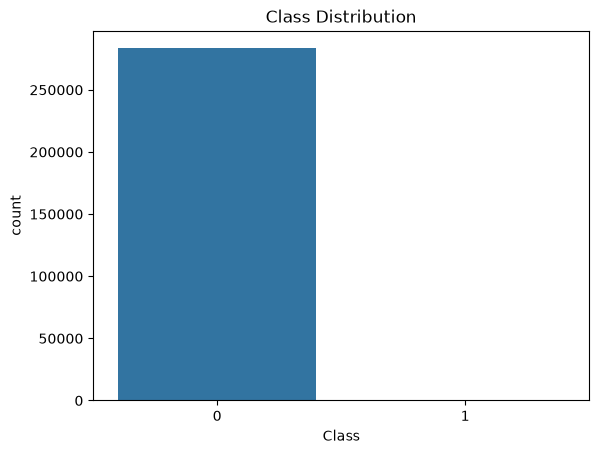

In [26]:
sns.countplot(data=df, x="Class")
plt.title("Class Distribution")
plt.show()

<Axes: xlabel='Class', ylabel='Amount'>

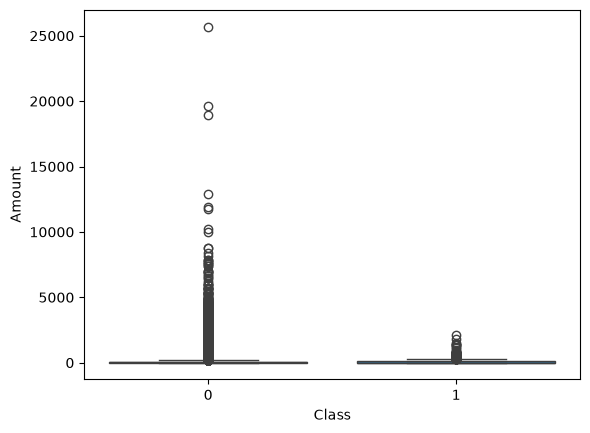

In [27]:
sns.boxplot(data=df, x="Class", y="Amount")

In [28]:
fraud_percentage = df["Class"].mean() * 100
print(f"Fraud transactions: {fraud_percentage:.3f}%")

Fraud transactions: 0.167%


In [29]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

In [30]:
df["Hour"] = (df["Time"] // 3600) % 24

In [31]:
df[["Time", "Hour"]].head(20)

,Time,Hour
0,0.0,0.0
1,0.0,0.0
2,1.0,0.0
3,1.0,0.0
4,2.0,0.0
5,2.0,0.0
6,4.0,0.0
7,7.0,0.0
8,7.0,0.0
9,9.0,0.0


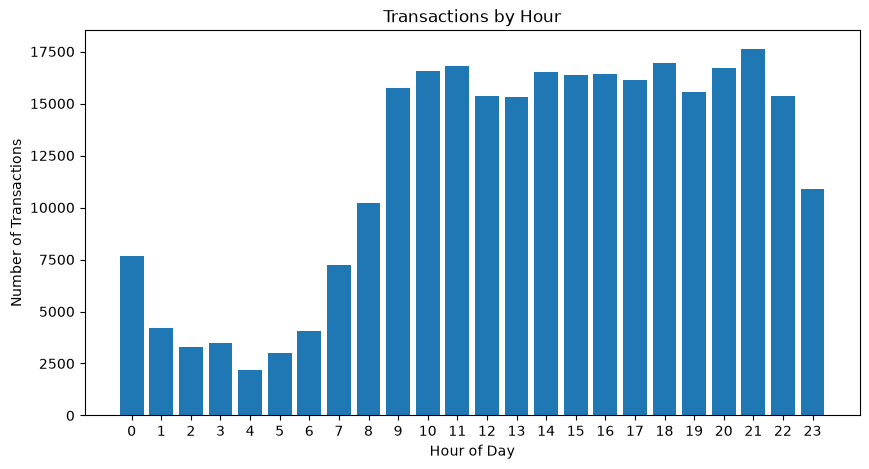

In [32]:
# Compare transaction counts by hour

hour_counts = df["Hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(hour_counts.index, hour_counts.values)

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(24))

plt.show()

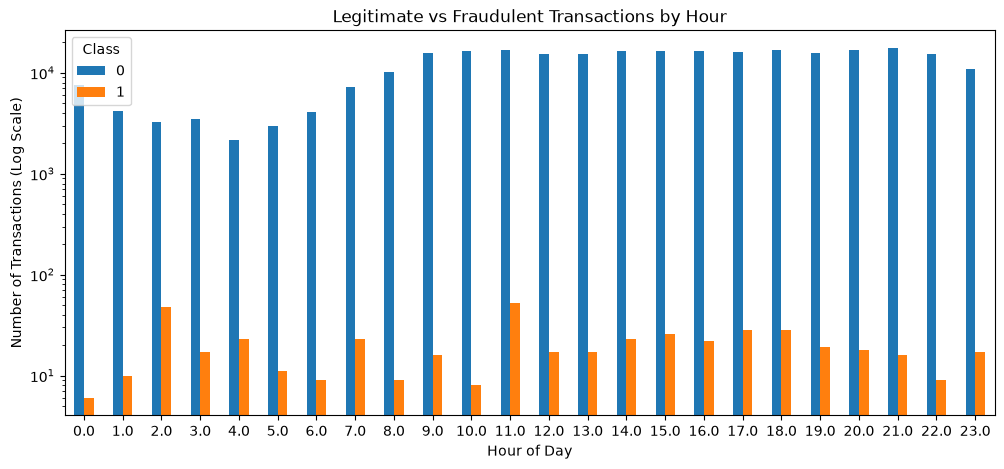

In [33]:
# Compare legitimate vs fraud transaction counts by hour

hour_class_counts = pd.crosstab(df["Hour"], df["Class"])

ax = hour_class_counts.plot(
    kind="bar",
    figsize=(12, 5)
)

ax.set_yscale("log")

plt.title("Legitimate vs Fraudulent Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions (Log Scale)")
plt.xticks(rotation=0)

plt.show()

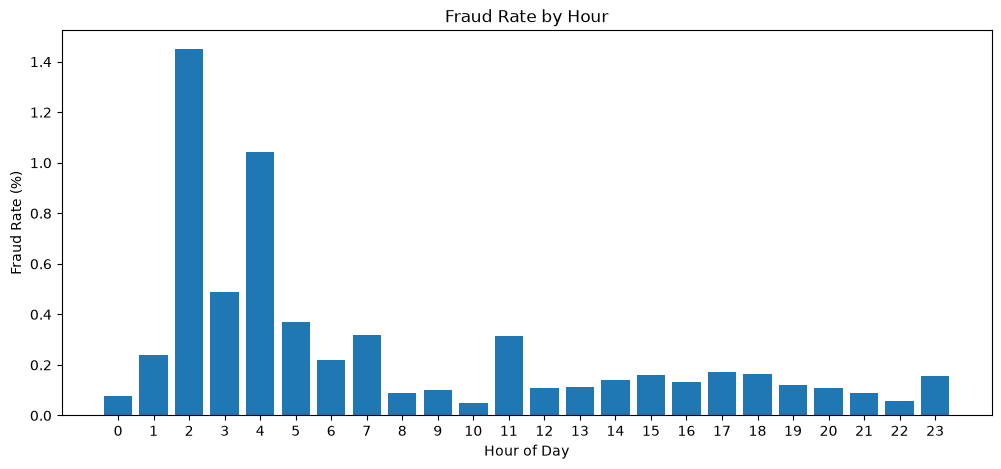

In [34]:
fraud_by_hour = (
    df.groupby("Hour")["Class"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(12, 5))

plt.bar(
    fraud_by_hour.index,
    fraud_by_hour.values
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

Analyze V1–V28 Features

In [35]:
v_features = [col for col in df.columns if col.startswith("V")]

print(v_features)
print("Number of V features:", len(v_features))

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Number of V features: 28


In [36]:
mean_by_class = df.groupby("Class")[v_features].mean().T

mean_by_class.head(5)

Class,0,1
V1,0.013439,-4.498280
V2,-0.009829,3.405965
V3,0.012853,-6.729599
V4,-0.010440,4.472591
V5,0.006769,-2.957197


In [37]:
# calculate the difference between the fraud and legitimate means.

mean_difference = (
    df[df["Class"] == 1][v_features].mean()
    - df[df["Class"] == 0][v_features].mean()
)

mean_difference.abs().sort_values(ascending=False).head(10)

V14    6.847614
V3     6.742452
V17    6.474249
V12    6.112730
V10    5.460937
V7     5.186359
V1     4.511719
V4     4.483031
V16    4.008801
V11    3.722350
dtype: float64

In [38]:
top_features = mean_difference.abs().sort_values(
    ascending=False
).head(5).index

print("Top 5 features:")
print(top_features)

Top 5 features:
Index(['V14', 'V3', 'V17', 'V12', 'V10'], dtype='str')


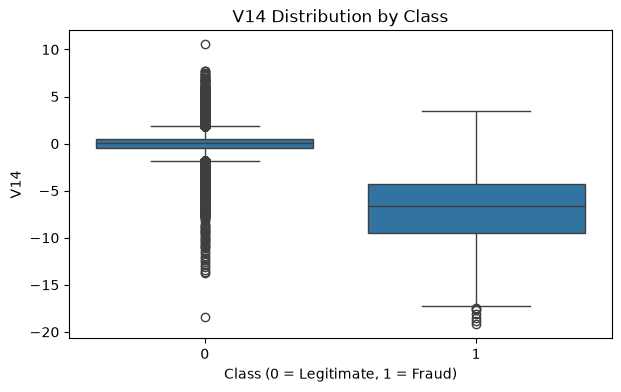

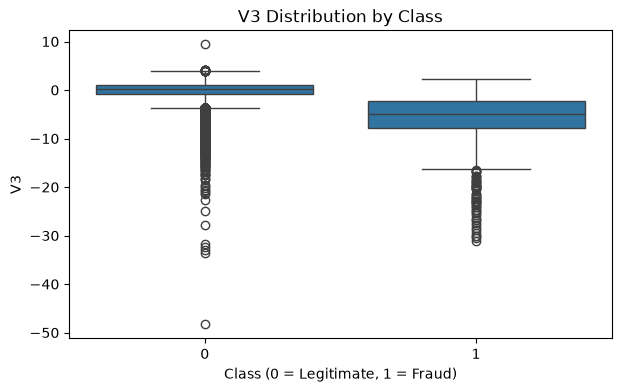

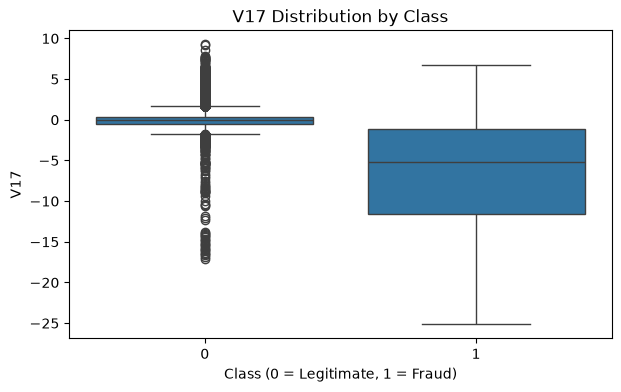

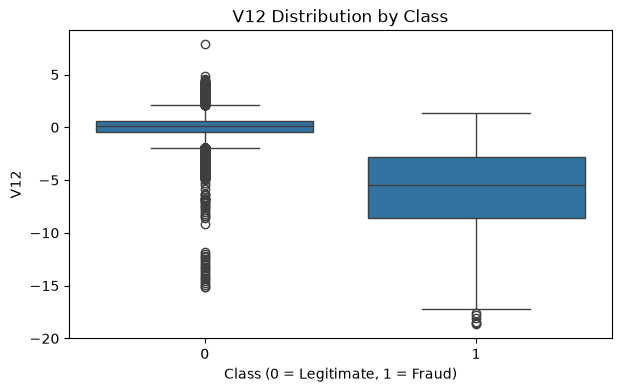

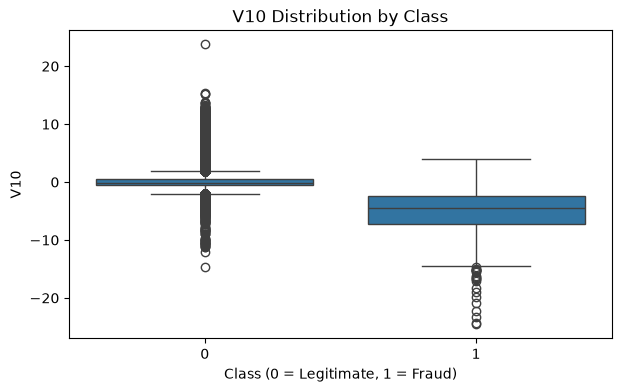

In [39]:
for feature in top_features:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        data=df,
        x="Class",
        y=feature
    )
    
    plt.title(f"{feature} Distribution by Class")
    plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
    plt.ylabel(feature)
    
    plt.show()

Correlation Analysis

In [40]:
correlation_with_class = df.corr(numeric_only=True)["Class"].sort_values(
    ascending=False
)

correlation_with_class

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
Hour     -0.016740
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64

In [41]:
correlation_with_class.abs().sort_values(
    ascending=False
).head(11)

Class    1.000000
V17      0.313498
V14      0.293375
V12      0.250711
V10      0.206971
V16      0.187186
V3       0.182322
V7       0.172347
V11      0.149067
V4       0.129326
V18      0.105340
Name: Class, dtype: float64

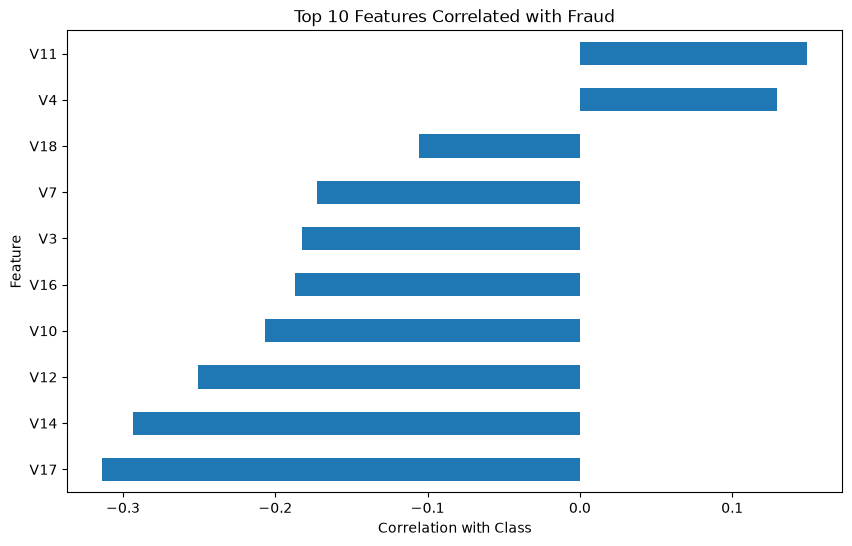

In [42]:
feature_correlations = correlation_with_class.drop("Class")

top_correlations = feature_correlations.abs().sort_values(
    ascending=False
).head(10)

top_correlations = feature_correlations[top_correlations.index]

plt.figure(figsize=(10, 6))

top_correlations.sort_values().plot(kind="barh")

plt.title("Top 10 Features Correlated with Fraud")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

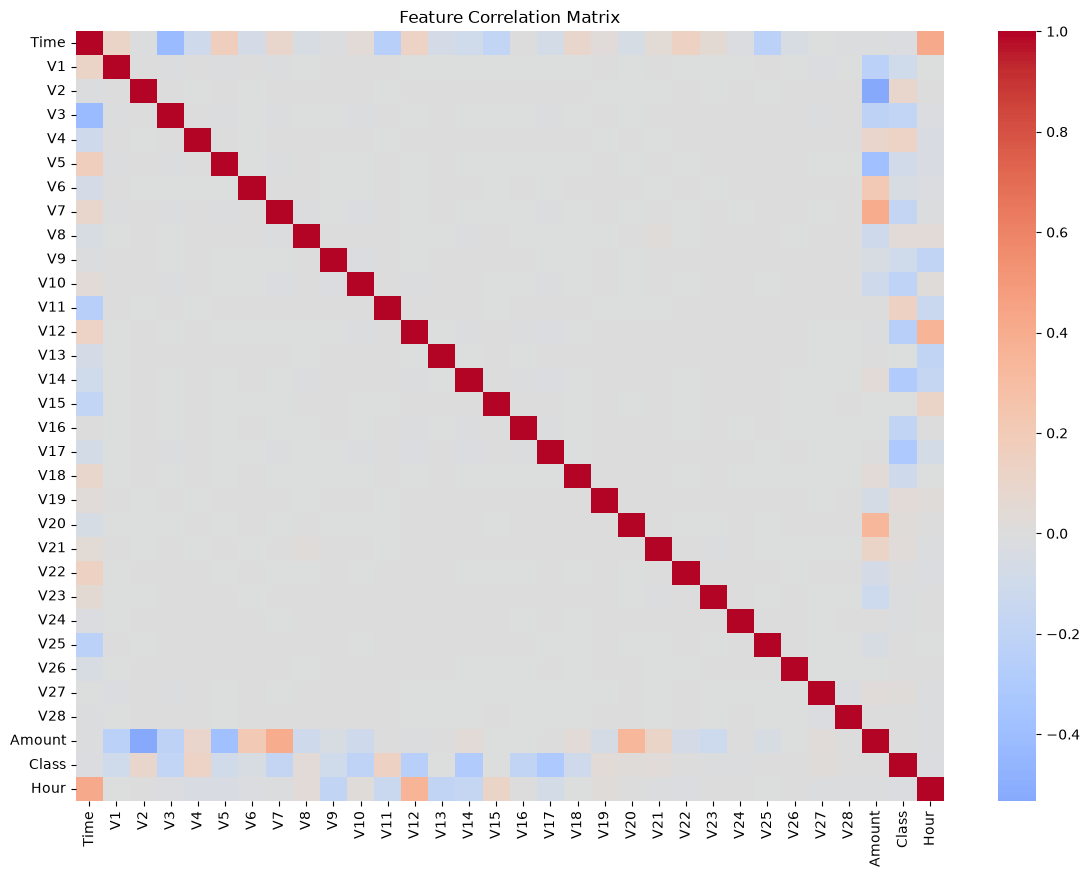

In [43]:
plt.figure(figsize=(14, 10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

Analyze the distributions of the important features

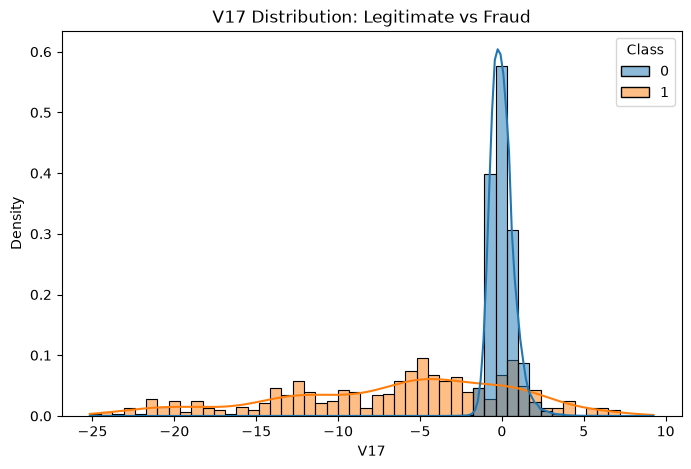

In [44]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="V17",
    hue="Class",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("V17 Distribution: Legitimate vs Fraud")
plt.xlabel("V17")
plt.ylabel("Density")

plt.show()

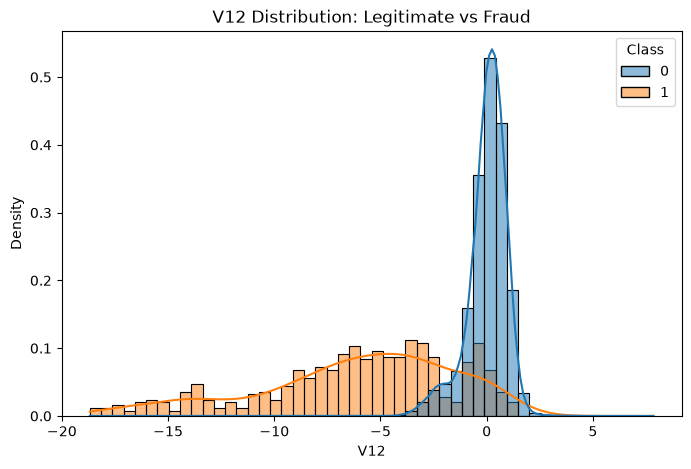

In [45]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="V12",
    hue="Class",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("V12 Distribution: Legitimate vs Fraud")
plt.xlabel("V12")
plt.ylabel("Density")

plt.show()

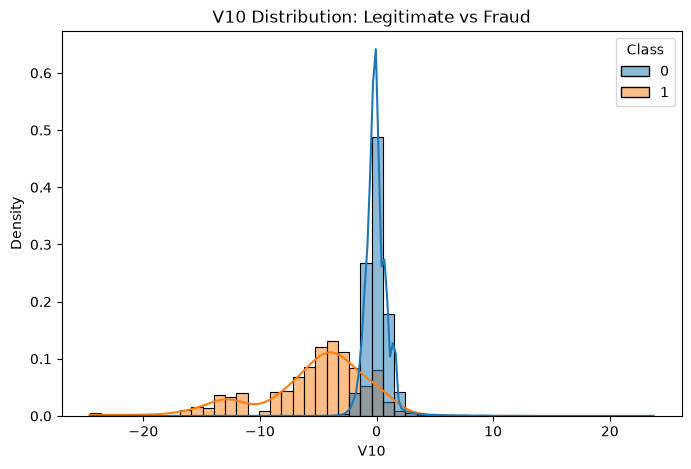

In [46]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="V10",
    hue="Class",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("V10 Distribution: Legitimate vs Fraud")
plt.xlabel("V10")
plt.ylabel("Density")

plt.show()

In [47]:
df["Day"] = (df["Time"] // 86400).astype(int)

In [48]:
df[["Time", "Day", "Hour"]].head(10)

,Time,Day,Hour
0,0.0,0,0.0
1,0.0,0,0.0
2,1.0,0,0.0
3,1.0,0,0.0
4,2.0,0,0.0
5,2.0,0,0.0
6,4.0,0,0.0
7,7.0,0,0.0
8,7.0,0,0.0
9,9.0,0,0.0


In [49]:

df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

In [50]:
df["Amount_log"] = np.log1p(df["Amount"])

In [51]:
df[["Amount", "Amount_log"]].head(10)

,Amount,Amount_log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539
5,3.67,1.541159
6,4.99,1.790091
7,40.80,3.732896
8,93.20,4.545420
9,3.68,1.543298


In [52]:
df[["Amount", "Amount_log"]].describe()

,Amount,Amount_log
count,283726.000000,283726.000000
mean,88.472687,3.153760
std,250.399437,1.657080
min,0.000000,0.000000
25%,5.600000,1.887070
50%,22.000000,3.135494
75%,77.510000,4.363226
max,25691.160000,10.153941


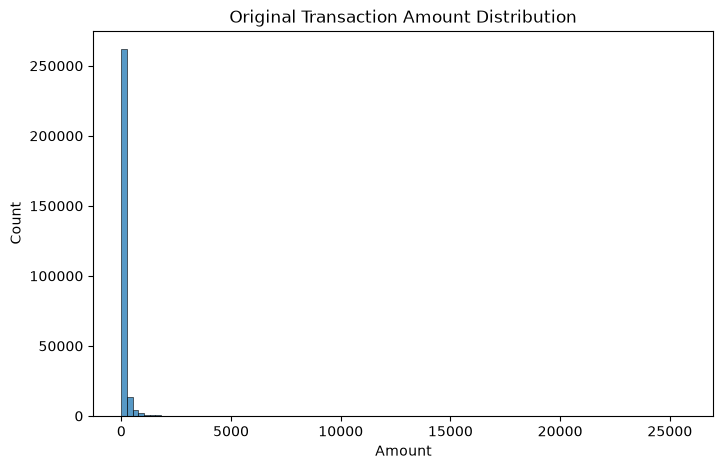

In [53]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Amount"], bins=100)

plt.title("Original Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")

plt.show()

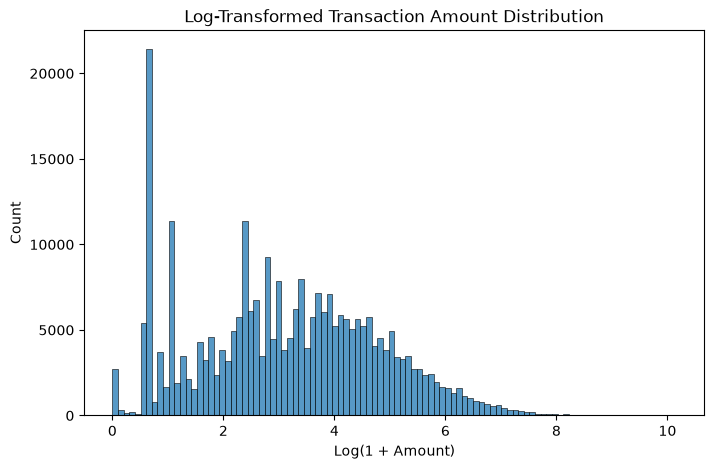

In [54]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Amount_log"], bins=100)

plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("Log(1 + Amount)")
plt.ylabel("Count")

plt.show()

In [55]:
df.shape

(283726, 36)

In [56]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Hour', 'Day', 'Hour_sin', 'Hour_cos', 'Amount_log'],
      dtype='str')

In [57]:
df[[
    "Time",
    "Day",
    "Hour",
    "Hour_sin",
    "Hour_cos",
    "Amount",
    "Amount_log",
    "Class"
]].head(10)

,Time,Day,Hour,Hour_sin,Hour_cos,Amount,Amount_log,Class
0,0.0,0,0.0,0.0,1.0,149.62,5.014760,0
1,0.0,0,0.0,0.0,1.0,2.69,1.305626,0
2,1.0,0,0.0,0.0,1.0,378.66,5.939276,0
3,1.0,0,0.0,0.0,1.0,123.50,4.824306,0
4,2.0,0,0.0,0.0,1.0,69.99,4.262539,0
5,2.0,0,0.0,0.0,1.0,3.67,1.541159,0
6,4.0,0,0.0,0.0,1.0,4.99,1.790091,0
7,7.0,0,0.0,0.0,1.0,40.80,3.732896,0
8,7.0,0,0.0,0.0,1.0,93.20,4.545420,0
9,9.0,0,0.0,0.0,1.0,3.68,1.543298,0


In [58]:
df.isnull().sum().sum()

np.int64(0)

In [59]:
df.to_csv(r"C:\\Users\\LENOVO\\Desktop\\fraud-detection-risk-scoring\\data\\processed\\cleaned_creditcard_processed.csv", index=False)